# First Classification attempt - Problem baseline

I'm going to use machine learning models to predict the injury status of the players with the data we have.
I do not expect to get good results, but I want to get a baseline to compare after improving the data and trying more advance techniques and models.

I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE, index_col=0)
Y = pd.read_csv(c.RICKD_BASELINE_Y_FILE, index_col=0)

print(f"X Dataset shape: {X.shape}")
print(f"X Columns: {list(X.columns)}")
display(X.head())

print(f"Y Dataset shape: {Y.shape}")
print(f"Y Columns: {list(Y.columns)}")
display(Y.head())

# Class imbalance
print(f"Class distribution: {Y['is_injured'].value_counts()}")
print(f"Class distribution: {Y['is_injured'].value_counts(normalize=True)}")

X Dataset shape: (1832, 93)
X Columns: ['speed_r', 'age', 'Height', 'Weight', 'YrsRunning', 'NumRaces', 'l_step_width', 'l_stride_rate', 'l_stride_length', 'l_swing_time', 'l_stance_time', 'l_pelvis_peak_drop_angle', 'l_pelvis_drop_excursion', 'l_ankle_df_peak_angle', 'l_ankle_eve_peak_angle', 'l_ankle_eve_percent_stance', 'l_ankle_eve_excursion', 'l_ankle_rot_peak_angle', 'l_ankle_rot_excursion', 'l_knee_flex_peak_angle', 'l_knee_add_peak_angle', 'l_knee_add_excursion', 'l_knee_abd_peak_angle', 'l_knee_abd_excursion', 'l_knee_rot_peak_angle', 'l_knee_rot_excursion', 'l_hip_ext_peak_angle', 'l_hip_add_peak_angle', 'l_hip_add_excursion', 'l_hip_rot_peak_angle', 'l_hip_rot_excursion', 'l_foot_prog_angle', 'l_foot_ang_at_hs', 'l_mhw_exc_from_to', 'l_ankle_eve_peak_vel', 'l_ankle_rot_peak_vel', 'l_knee_abd_peak_vel', 'l_knee_add_peak_vel', 'l_hip_abd_peak_vel', 'l_knee_rot_peak_vel', 'l_hip_rot_peak_vel', 'l_pronation_onset', 'l_pronation_offset', 'l_peak_hip_add_velocity', 'l_peak_pelvic_

,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005t132240,-2.406926,1.231321,-11.741497,-5.056746,0.578686,-0.393107,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-1.935588,False,False,False,False,False,False,True
100434_20101117t132240,-1.095016,1.066816,-11.741497,-5.056746,1.308477,-0.393107,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.344740,True,False,False,False,False,False,True
100537_20120703t102550,-1.325076,-3.128072,0.097259,-0.179365,-0.568129,-0.393107,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.284941,True,False,False,False,True,False,True
100560_20120717t103748,-0.215279,-0.413733,0.521293,0.931754,-0.776641,-0.393107,0.677045,-1.610390,0.439240,-1.165155,...,3.526927,-1.746297,1.346349,True,False,False,False,True,False,True
101481_20120717t105021,-0.282875,-0.495986,0.316116,-0.828721,-0.776641,-0.393107,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.657459,True,False,False,False,False,False,False


Y Dataset shape: (1832, 13)
Y Columns: ['injury_severity_code', 'injury_severity_value', 'injury_code', 'injury2_code', 'injury_desc', 'injury2_desc', 'injury_name', 'injury2_name', 'injured_joint_code', 'injured_joint2_code', 'injured_side_code', 'injured_side2_code', 'is_injured']


,injury_severity_code,injury_severity_value,injury_code,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,is_injured
id,,,,,,,,,,,,,
100433_20101005t132240,volume_intensity,2.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,1
100434_20101117t132240,volume_intensity,2.0,disc_dege,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,1
100537_20120703t102550,missed_2_workouts,3.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,1
100560_20120717t103748,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,0
101481_20120717t105021,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,0


Class distribution: is_injured
1    1167
0     665
Name: count, dtype: int64
Class distribution: is_injured
1    0.637009
0    0.362991
Name: proportion, dtype: float64


In [3]:
y = Y["is_injured"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1465 samples
Test set: 367 samples


In [4]:
# Save train and test sets to disk for reproducibility
X_train.to_csv(c.RICKD_BASELINE_X_TRAIN_FILE)
X_test.to_csv(c.RICKD_BASELINE_X_TEST_FILE)
y_train.to_csv(c.RICKD_BASELINE_Y_TRAIN_FILE)
y_test.to_csv(c.RICKD_BASELINE_Y_TEST_FILE)

In [5]:
# Load train and test sets from disk
X_train = pd.read_csv(c.RICKD_BASELINE_X_TRAIN_FILE, index_col=0)
X_test = pd.read_csv(c.RICKD_BASELINE_X_TEST_FILE, index_col=0)
y_train = pd.read_csv(c.RICKD_BASELINE_Y_TRAIN_FILE, index_col=0).squeeze()
y_test = pd.read_csv(c.RICKD_BASELINE_Y_TEST_FILE, index_col=0).squeeze()

## Model configuration

In [ ]:
models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__subsample': [0.8, 0.9, 1.0]
        }
    },
    
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto', 0.1, 0.01]
        }
    }
}


## Train Models with Grid Search

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trained_models = {}
results = {}

for model_name, config in models_config.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)
    
    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    trained_models[model_name] = grid_search
    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    y_pred_proba = grid_search.predict_proba(X_test)
    
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='weighted')
    test_recall = recall_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    
    results[model_name].update({
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    })
    
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print(f"Test ROC AUC: {test_roc_auc:.4f}")


Training Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best CV Score: 0.7583
Best Parameters: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Test Accuracy: 0.7766
Test Precision: 0.7793
Test Recall: 0.7766
Test F1-Score: 0.7632
Test ROC AUC: 0.7818

Training Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV Score: 0.8180
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Test Accuracy: 0.7820
Test Precision: 0.8179
Test Recall: 0.7820
Test F1-Score: 0.7561
Test ROC AUC: 0.7763

Training XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best CV Score: 0.8171
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200, 'classifier__subsample': 0.9}
Test Accuracy: 0.8065
Test Precision: 0.8139
Test Reca

In [8]:
target_folder = c.RICKD_BASELINE_RESULTS_FOLDER
os.makedirs(target_folder, exist_ok=True)

# Save trained models
model_filenames = {}
for model_name, result in results.items():
    model_obj = trained_models[model_name]
    filename = f"{model_name.lower().replace(' ', '_')}_model.pkl"
    model_file = os.path.join(target_folder, filename)
    joblib.dump(model_obj, model_file)
    model_filenames[model_name] = model_file
    print(f"Model '{model_name}' saved to: {model_file}")

# Save results:
results_list = []
for model_name, result in results.items():
    gridsearch = trained_models[model_name]
    best_params = getattr(gridsearch, "best_params_", None)
    best_score = getattr(gridsearch, "best_score_", None)
    results_list.append(
        ResultModel(
            model_name=model_name,
            model_file=model_filenames[model_name],
            test_accuracy=float(result['test_accuracy']),
            test_precision=float(result['test_precision']),
            test_recall=float(result['test_recall']),
            test_f1=float(result['test_f1']),
            test_roc_auc=float(result['test_roc_auc']),
            y_pred=result['y_pred'].tolist(),
            y_pred_proba=result['y_pred_proba'].tolist(),
            best_parameters=best_params,
            best_score=float(best_score) if best_score is not None else None,
        )
    )

results_model = ResultsModel(results=results_list)

with open(c.RICKD_BASELINE_RESULTS_SUMMARY_FILE, "w") as f:
    f.write(results_model.model_dump_json(indent=2))

print(f"Results summary saved to: {c.RICKD_BASELINE_RESULTS_SUMMARY_FILE}")

Model 'Logistic Regression' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV2/logistic_regression_model.pkl
Model 'Random Forest' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV2/random_forest_model.pkl
Model 'XGBoost' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV2/xgboost_model.pkl
Model 'SVM' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV2/svm_model.pkl
Results summary saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV2/results_summary.json


### Checkpoint: Load results and models

In [9]:
# Load results from JSON and pickle files
with open(c.RICKD_BASELINE_RESULTS_SUMMARY_FILE, "r") as f:
    results_json = f.read()
results_model_loaded = ResultsModel.model_validate_json(results_json)

results_loaded = {}
trained_models_loaded = {}
for result in results_model_loaded.results:
    results_loaded[result.model_name] = {
        'test_accuracy': result.test_accuracy,
        'test_precision': result.test_precision,
        'test_recall': result.test_recall,
        'test_f1': result.test_f1,
        'test_roc_auc': result.test_roc_auc,
        'y_pred': np.array(result.y_pred),
        'y_pred_proba': np.array(result.y_pred_proba),
        'best_parameters': result.best_parameters,
        'best_score': result.best_score,
    }
    trained_models_loaded[result.model_name] = joblib.load(result.model_file)

results = results_loaded
trained_models = trained_models_loaded

## Analysis of Models

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test Accuracy  Test Precision  \
2              XGBoost        0.8126         0.8065          0.8139   
3                  SVM        0.8054         0.7193          0.8051   
0  Logistic Regression        0.7818         0.7766          0.7793   
1        Random Forest        0.7763         0.7820          0.8179   

   Test Recall  Test F1-Score  
2       0.8065         0.7953  
3       0.7193         0.6560  
0       0.7766         0.7632  
1       0.7820         0.7561  

Best performing model: XGBoost
Best Test ROC AUC Score: 0.8126


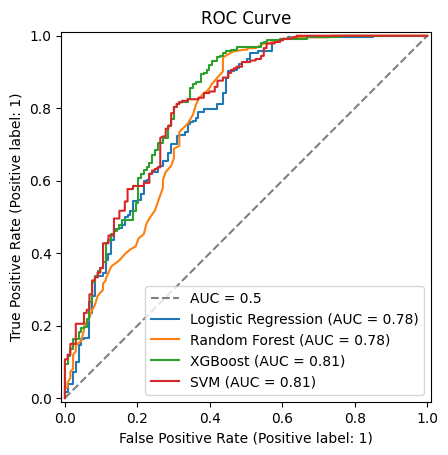

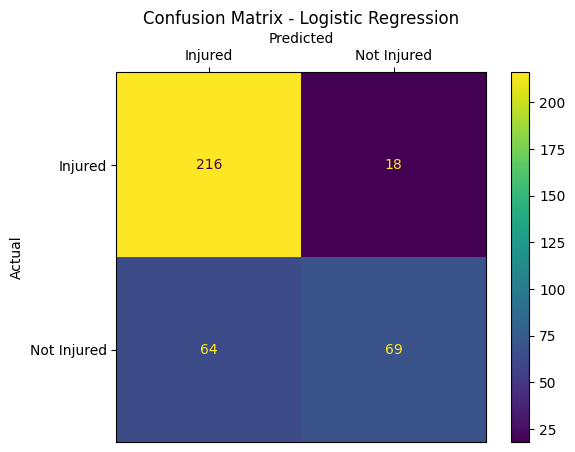

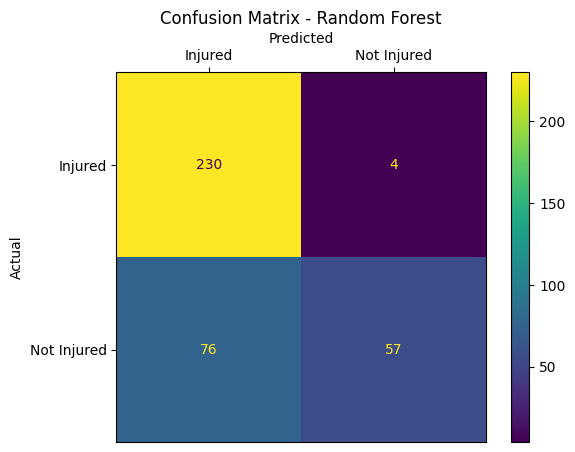

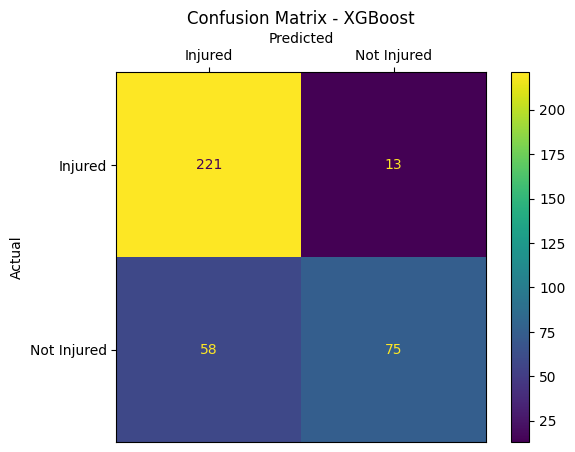

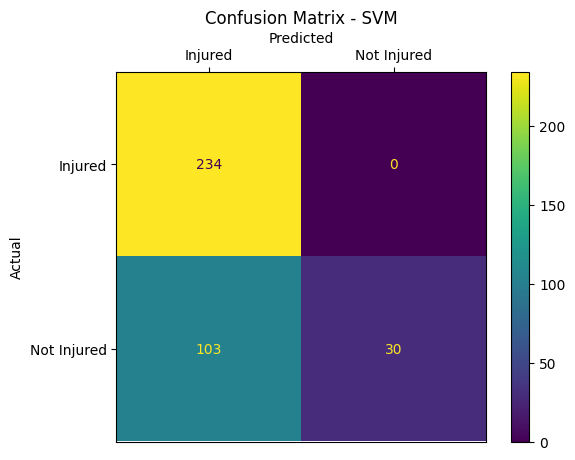

In [10]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['test_roc_auc'],
        'Test Accuracy': result['test_accuracy'],
        'Test Precision': result['test_precision'],
        'Test Recall': result['test_recall'],
        'Test F1-Score': result['test_f1'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'][:, 1], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")